In [1]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO

  Activating project at `~/Phd/SSDdev`


In [2]:

T = Float32


Float32

In [3]:
save_sim_path = "saved_simulation/sim_sf.h5"

recalculate = false   # <<<<<<<< CAMBIA QUI
if isfile(save_sim_path) && !recalculate
    println("⚡ Upoload simulation saved in : $save_sim_path")
    sim_sf = ssd_read(save_sim_path, Simulation)

else
    
    println("🔧 New simulation for the electric potential...")
    sim_sf = Simulation{T}(SSD_examples[:InvertedCoax])
    sim_sf.detector = SolidStateDetector(sim_sf.detector, contact_id=2, contact_potential=3500u"V")
    grid = Grid(sim_sf, max_tick_distance = 5u"mm")
    println("🔧 New simulation for the electric potential...")
    calculate_electric_potential!(sim_sf, grid = grid)
    println("🔧 New simulation for the electric field...")
    calculate_electric_field!(sim_sf)
    println("🔧 New simulation for the weighting potential...")
    calculate_weighting_potential!(sim_sf, 1, refinement_limits = [0.2, 0.1]; grid = sim_sf.electric_potential.grid)

    println("💾 Saving simulation in $save_sim_path")
    ssd_write(save_sim_path, sim_sf)
end

⚡ Upoload simulation saved in : saved_simulation/sim_sf.h5
Simulation{Float32, Cylindrical} - Coordinate system: Cylindrical
  Environment Material: Vacuum
  Detector: Public Inverted Coax
  Electric potential: (66, 1, 100)
  Charge density: (66, 1, 100)
  Impurity scale: (66, 1, 100)
  Fix Charge density: (66, 1, 100)
  Dielectric distribution: (67, 2, 101)
  Point types: (66, 1, 100)
  Electric field: (66, 36, 100)
  Weighting potentials: 
    Contact 1: (66, 1, 100)
    Contact 2: missing


In [4]:
sim = sim_sf 

Simulation{Float32, Cylindrical} - Coordinate system: Cylindrical
  Environment Material: Vacuum
  Detector: Public Inverted Coax
  Electric potential: (66, 1, 100)
  Charge density: (66, 1, 100)
  Impurity scale: (66, 1, 100)
  Fix Charge density: (66, 1, 100)
  Dielectric distribution: (67, 2, 101)
  Point types: (66, 1, 100)
  Electric field: (66, 36, 100)
  Weighting potentials: 
    Contact 1: (66, 1, 100)
    Contact 2: missing


In [5]:
sim.electric_potential.grid.axes[1]

0.0 .. 0.04 - length = 66

In [6]:
using Plots
gr()


Plots.GRBackend()

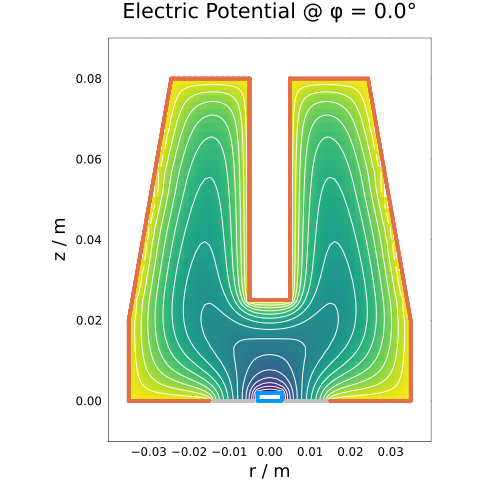

In [162]:

p = plot(
    ElectricPotential(
        sim.electric_potential.data .* replace(
            SolidStateDetectors.is_pn_junction_point_type.(
                length(sim.electric_potential.grid.φ) == 1 ? 
                    sim.point_types.data : 
                    SolidStateDetectors.get_2π_potential(sim.point_types).data
            ), 0 => T(NaN)
        ),
        sim.electric_potential.grid
    ),
    full_det = true,
    φ = 0, color = :viridis,
    contours_equal_potential = true,
    linecolor = :White,
    legend = false,
      # tick verso l’interno
)


# Aggiungi slice del detector
plot!(sim.detector, full_det=true, st=:slice, lw=2, φ=0)



plot!(framestyle = :box,
    grid = true,
    gridalpha = 5,
    size = (500, 500),
    guidefontsize = 12,
    tickfont = font(8),
    tick_length = 6,         # lunghezza del tick in pixel
    tick_direction = :in   )
    
x_ticks_cm = -0.04:0.02:0.04
y_ticks_cm = -0.010:0.02: 0.09

# Etichette in mm
using Printf

plot!(p,)




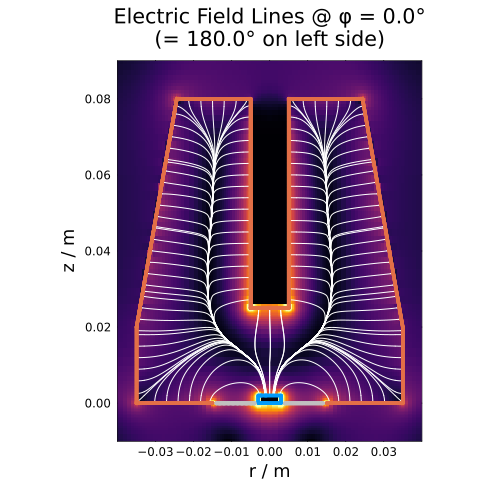

In [161]:

plot(sim.electric_field, full_det = true, size = (500,500), clims = (0,5e5), legend = false)
plot_electric_fieldlines!(sim, full_det = true, sampling = 3u"mm", offset = 2u"mm")

# Aggiungi slice del detector
plot!(sim.detector, full_det=true, st=:slice, lw=2, φ=0)
plot!(framestyle = :box,
    grid = true,
    gridalpha = 5,
    size = (500, 500),
    guidefontsize = 12,
    tickfont = font(8),
    tick_length = 6,         # lunghezza del tick in pixel
    tick_direction = :in   )





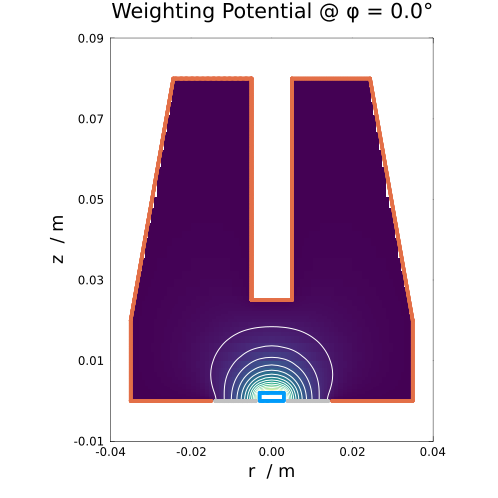

In [163]:
p = plot(
    WeightingPotential(
        # multiply all entries in the electric potential that are NOT part of the semiconductor with NaN
        sim.weighting_potentials[1].data .* replace(SolidStateDetectors.is_pn_junction_point_type.(
                length(sim.weighting_potentials[1].grid.φ) == 1 ? sim.point_types.data : SolidStateDetectors.get_2π_potential(sim.point_types).data
            ), 0 => T(NaN)),
        sim.weighting_potentials[1].grid
    ), full_det=true, φ=0, contours_equal_potential=true, linecolor=:White, legend=false, framestyle=:box, grid=true
)


# Aggiungi slice del detector
plot!(sim.detector, full_det=true, st=:slice, lw=2, φ=0, xunit = u"m", yunit = u"m", zunit = u"m", xlabel="r ", ylabel="z ")



plot!(framestyle = :box,
    grid = true,
    gridalpha = 5,
    size = (500, 500),
    guidefontsize = 12,
    tickfont = font(8),
    tick_length = 6,         # lunghezza del tick in pixel
    tick_direction = :in   )
    
x_ticks_cm = -0.04:0.02:0.04
y_ticks_cm = -0.010:0.02: 0.09

# Etichette in mm
using Printf

plot!(p,)

x_labels = [@sprintf("%.2f", x) for x in x_ticks_cm]  # 1 decimale
y_labels = [@sprintf("%.2f", y) for y in y_ticks_cm]  # 2 decimali se vuoi


# Applica ticks distanziati
xticks!(p, x_ticks_cm, x_labels)
yticks!(p, y_ticks_cm, y_labels)

In [ ]:
starting_positions = [ CartesianPoint{T}( 0.020, 0, 0.015 )]
                       #CartesianPoint{T}( 0.015, deg2rad(20), 0.045 ),
                       #CartesianPoint{T}( 0.022, deg2rad(35), 0.025 ) ]
energy_depos = T[1460, 609, 1000] * u"keV" # are needed later in the signal generation

evt = Event(starting_positions, energy_depos);

time_step = 5u"ns"
drift_charges!(evt, sim, Δt = time_step)

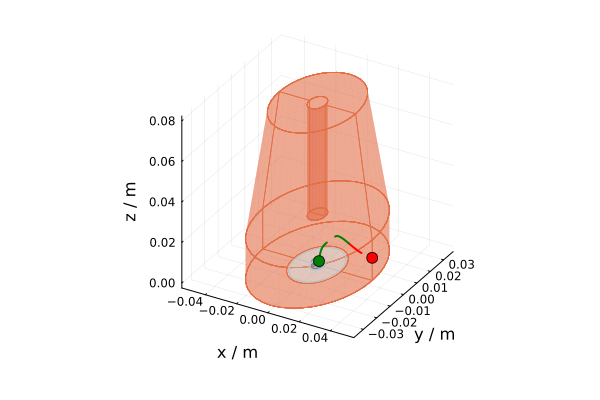

In [49]:
plot(sim.detector,  legend = false)
plot!(evt.drift_paths, linewidth = 2, linestyle = :dash, markersize = 6)


In [151]:
starting_positions = [ CartesianPoint{T}( 0.020, 0, 0.015 ),
                       CartesianPoint{T}( -0.015, -0.02, 0.045 ),
                       CartesianPoint{T}( -0.022, 0.015, 0.025 ) ]
energy_depos = T[1460, 609, 1000] * u"keV" # are needed later in the signal generation

evt = Event(starting_positions, energy_depos);

In [152]:
drift_charges!(evt, sim, Δt = 5u"ns")
evt.drift_paths

3-element Vector{SolidStateDetectors.EHDriftPath{Float32}}:
 SolidStateDetectors.EHDriftPath{Float32}(CartesianPoint{Float32}[CartesianPoint{Float32}(0.02f0, 0.0f0, 0.015f0), CartesianPoint{Float32}(0.020429624f0, -2.4617908f-11, 0.0148202f0), CartesianPoint{Float32}(0.02086453f0, -4.0882662f-11, 0.014636956f0), CartesianPoint{Float32}(0.021304617f0, -6.6185224f-11, 0.014451316f0), CartesianPoint{Float32}(0.021749854f0, -9.2505954f-11, 0.014264359f0), CartesianPoint{Float32}(0.022199914f0, -1.1695661f-10, 0.014076166f0), CartesianPoint{Float32}(0.022655776f0, -1.2128372f-10, 0.013888234f0), CartesianPoint{Float32}(0.02311801f0, -1.2527095f-10, 0.013701663f0), CartesianPoint{Float32}(0.023585614f0, -1.4900775f-10, 0.013516856f0), CartesianPoint{Float32}(0.024058007f0, -1.6670956f-10, 0.013334158f0)  …  CartesianPoint{Float32}(0.030238412f0, -3.9956635f-10, 0.011589955f0), CartesianPoint{Float32}(0.030800385f0, -4.018561f-10, 0.01150242f0), CartesianPoint{Float32}(0.03137061f0, -4.066843

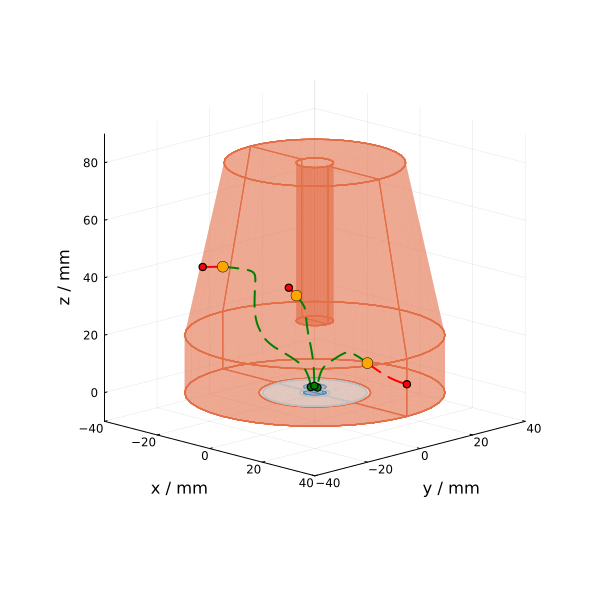

In [153]:
plot(sim.detector, size = (600,600), 
    xunit = u"mm", yunit = u"mm", zunit = u"mm", xlims = (-40,40), ylims = (-40,40), zlims = (-10,90), camera = (45, 15), legend = false
    )
plot!(evt.drift_paths, linewidth = 2, linestyle = :dash, legendfontsize = 10)
plot!(vcat(evt.locations...), color = :orange, markersize = 6, label = "")

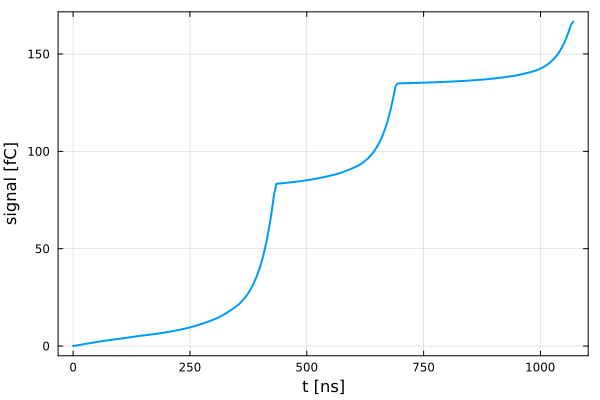

In [154]:

simulate!(evt, sim, Δt = 5u"ns")
plot(u"ns", u"fC", framestyle = :box,)
plot!(evt.waveforms, linewidth = 2, legend = false)